<a href="https://colab.research.google.com/github/Jayapriya49/Applied-AI/blob/main/ex11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
import zipfile

with zipfile.ZipFile("dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

print("Done")

Done


In [ ]:
import os
print(os.listdir("dataset"))

['valid', 'train']


In [ ]:
import torch
from torchvision import datasets, transforms, models
from torch import nn, optim
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
train_dir = "dataset/train"
valid_dir = "dataset/valid"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(train_dir, transform=transform)
valid_data = datasets.ImageFolder(valid_dir, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=8, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=8)

print("Classes:", train_data.classes)

Classes: ['Albert_Einstein', 'abdul_kalam']


In [ ]:
model = models.resnet18(weights="DEFAULT")

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 300MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 5.561202824115753
Epoch 2, Loss: 4.014060854911804
Epoch 3, Loss: 3.2981742918491364
Epoch 4, Loss: 2.998347371816635
Epoch 5, Loss: 2.3331141620874405


In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Model saved")

Model saved


In [ ]:
uploaded = files.upload()

Saving Screenshot 2026-04-06 142750.png to Screenshot 2026-04-06 142750.png


Prediction: Albert_Einstein


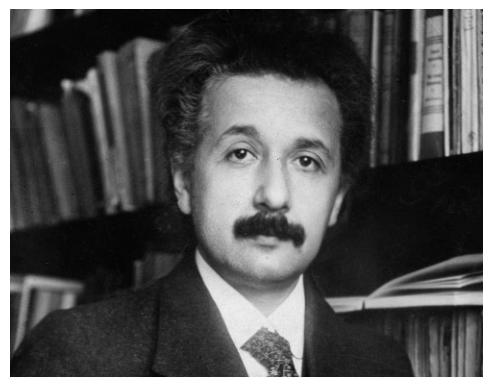

In [ ]:
model.eval()

img_path = list(uploaded.keys())[0]
img = Image.open(img_path).convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img_tensor = transform(img).unsqueeze(0)

output = model(img_tensor)
pred = torch.argmax(output, dim=1)

print("Prediction:", train_data.classes[pred.item()])

plt.imshow(img)
plt.axis("off")
plt.show()